<a href="https://colab.research.google.com/github/surajkrpirari2007/surajkasdj/blob/main/placement_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
data=pd.read_csv("college_student_placement_dataset.csv")

warnings.filterwarnings('ignore')

data1=data.copy()
data1.columns
data1.info()
data1['Communication_Skills'].value_counts()
data1['Projects_Completed'].value_counts()

data1['Academic_Performance'].fillna(data1['Academic_Performance'].mode()[0],inplace=True)
data1.drop(columns="College_ID",inplace=True)
data1.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No
5,96,5.26,5.32,7,No,5,8,0,No
6,123,6.68,6.58,5,No,7,8,2,Yes
7,111,8.77,8.76,7,No,3,1,2,Yes
8,92,6.47,6.33,9,No,7,8,5,No
9,108,8.82,8.60,4,No,5,9,1,No


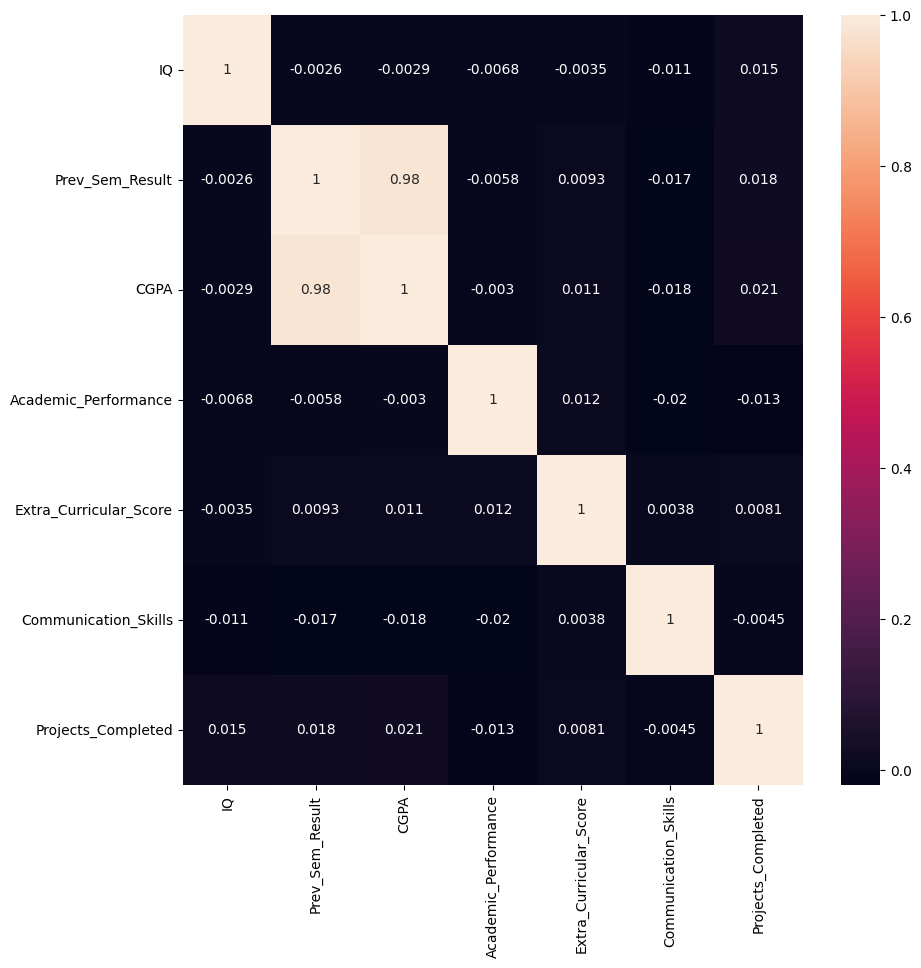

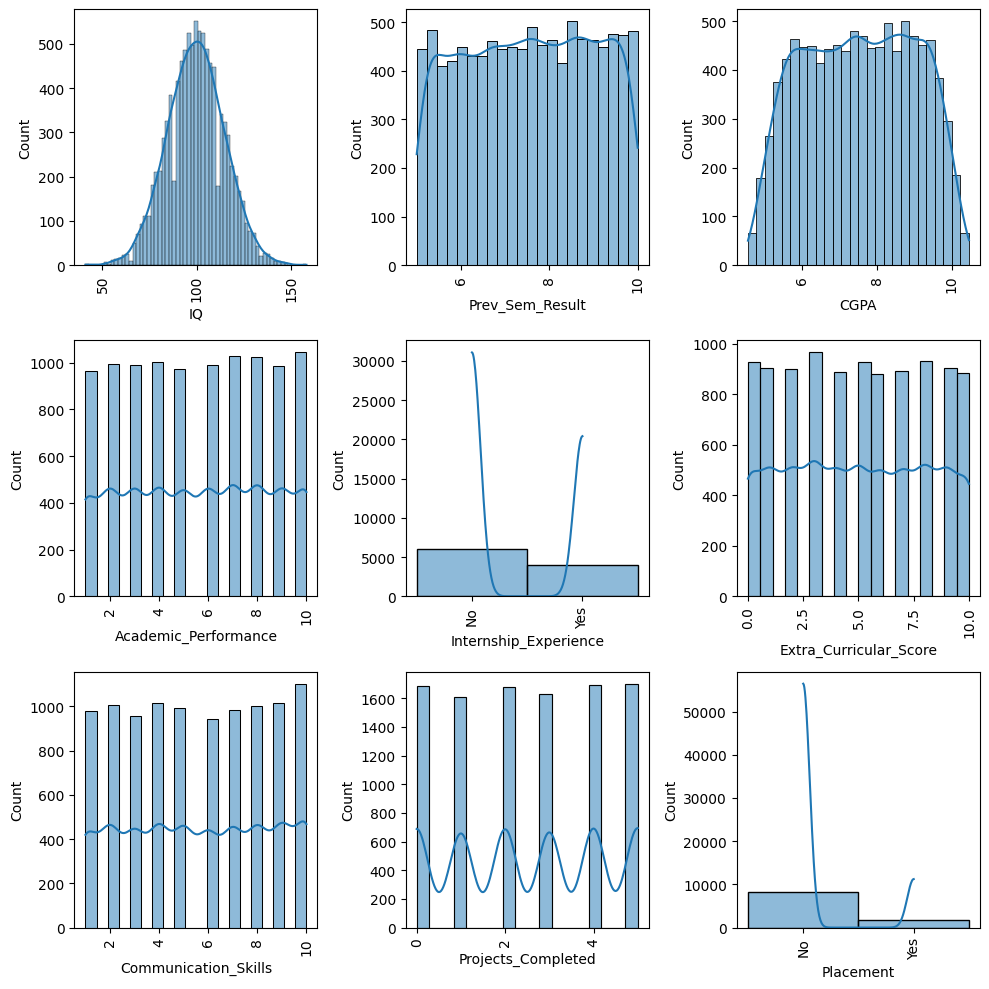

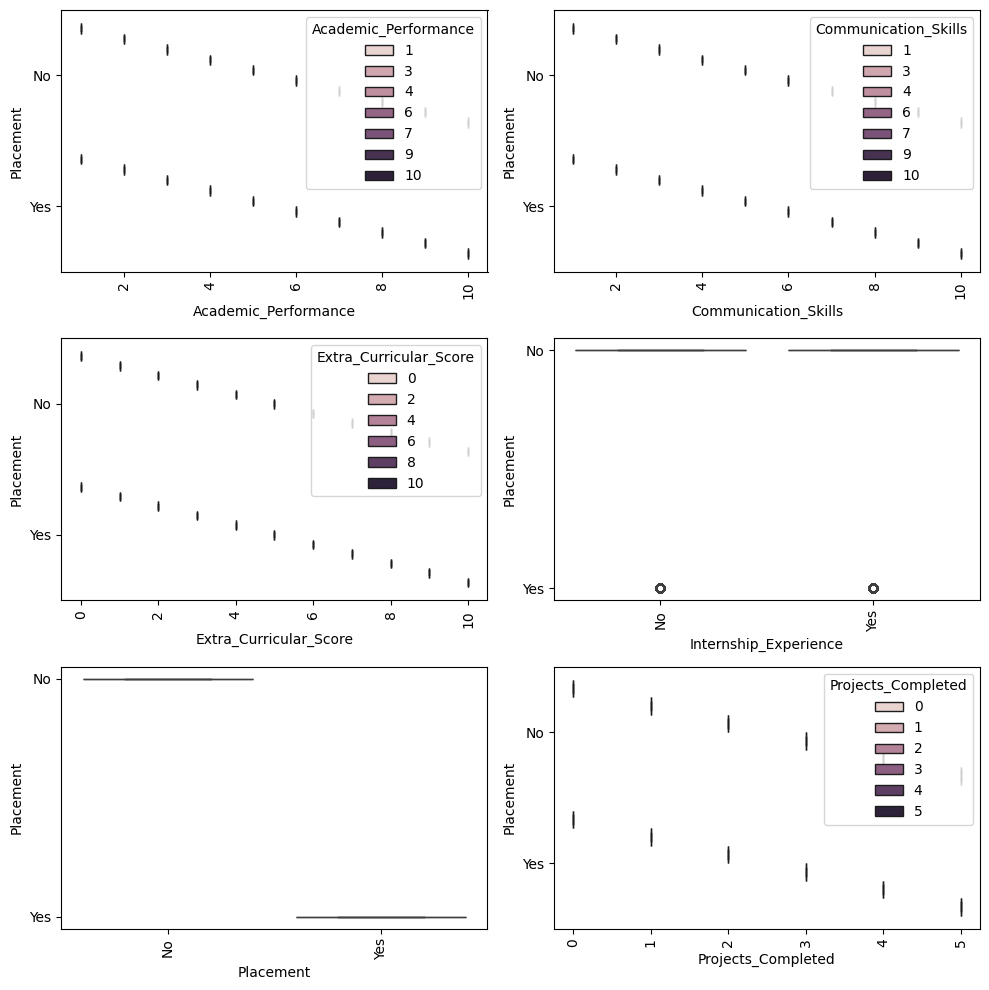

In [26]:
plt.figure(figsize=(10,10))
sns.heatmap(data1.corr(numeric_only=True),annot=True)
plt.show()

plt.figure(figsize=(10,10))
count=1
for col in data1.columns:
  plt.subplot(3,3,count)
  sns.histplot(data1[col],kde=True)
  count+=1
  plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

cc_list=data1.columns.difference(["IQ","Prev_Sem_Result","CGPA"]).to_list()
cc_list
plt.figure(figsize=(10,10))
count2=1
for col2 in cc_list:
  plt.subplot(3,2,count2)
  sns.boxplot(x=data1[col2],y=data1['Placement'],hue=data1[col2])
  count2+=1
  plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [27]:
data1['Internship_Experience']=data1['Internship_Experience'].map({'No':0,'Yes':1})
data1['Placement']=data1['Placement'].map({'No':0,'Yes':1})
x=data1.drop(columns='Placement')
y=data1['Placement']


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
scaler=StandardScaler()
x=scaler.fit_transform(x)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model_lr=LogisticRegression()
model_lr.fit(x_train,y_train)


LogisticRegression()

In [29]:
y_pred=model_lr.predict(x_test)
display(y_pred[:20])
display(y_test.head(20))

acc_sc=accuracy_score(y_test,y_pred)
con_mat=confusion_matrix(y_test,y_pred)
class_rep=classification_report(y_test,y_pred)
print(acc_sc,"\n",con_mat,'\n',class_rep)

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

,Placement
6252,0
4684,0
1731,0
4742,0
4521,1
6340,0
576,1
5202,0
6363,0
439,0


0.9035 
 [[1609   65]
 [ 128  198]] 
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


base_model=[
    ('svm', SVC(C=1)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=1000))
]
meta_model=[
    ('lr', LogisticRegression())
]
stack_model=StackingClassifier(
    estimators=base_model,
    final_estimator=meta_model[0][1],
    cv=5
)

stack_model.fit(x_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('svm', SVC(C=1)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(max_depth=1000))],
                   final_estimator=LogisticRegression())

In [32]:
predicting=stack_model.predict(x_test)
display(predicting[:20])
display(y_test.head(20))

acc_sc_stk=accuracy_score(y_test,predicting)
con_mat_stk=confusion_matrix(y_test,predicting)
class_rep_stk=classification_report(y_test,predicting)
print(acc_sc_stk,"\n",con_mat_stk,'\n',class_rep_stk)


array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

,Placement
6252,0
4684,0
1731,0
4742,0
4521,1
6340,0
576,1
5202,0
6363,0
439,0


1.0 
 [[1674    0]
 [   0  326]] 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

